# Implementation of the Ballistic-Benamou-Brenier formulation using Taichi reverse autodiff

**First order optimization**

The BBB formulation of an evolution EDO or PDE requires minimizing a convex functional over a vector space of large dimension (due to the discretization in time and space). So far we have considered two optimization methods : 
- Newton. 
    * Pros : quadratic convergence rate, simple implementation using autodiff.
    * Cons : requires assembling and then inverting large sparse matrices, which limits the problem dimension. Needs a logarithmic barrier for positive definiteness.
        
- Proximal.
    * Pros : scales to large problem sizes (makes sense in infinite dimension), takes advantage of the FFT.
    * Cons : error prone implementation, including duplication of variables, computation of proximal operators. Several parameters. Slow convergence.
   

We consider here an intermediate option, based on the first order derivatives of the energy functional, rather than second order derivatives (Newton) or zeroth order (proximal method). 
- Pros : simple and reasonably efficient implementation using Taichi backpropagation. Linear (for gradient descent), or possibly quadratic (for LBFGS) convergence rate.
- Cons : we'll see.


## 0. Importing the required libraries

In [15]:
agd_path = "/Users/jean-mariemirebeau/Dropbox/Programmes/GithubM1/AdaptiveGridDiscretizations"; agdt_path = "/Users/jean-mariemirebeau/Dropbox/Programmes/GithubM1/AGDT/AdaptiveGridDiscretizations_Taichi"
import sys; sys.path.insert(0,agd_path); sys.path.insert(0,agdt_path)

In [94]:
import taichi as ti
import numpy as np
from agd import AutomaticDifferentiation as ad
from agd import LinearParallel as lp
from matplotlib import pyplot as plt
from scipy.optimize import minimize


float_t = ti.f64
ti.init(arch=ti.cpu,default_fp=float_t) # Default data types are f32 et i32

[Taichi] Starting on arch=arm64


### 0.1 Additional functions

In [267]:
# First order differentiation

def mk_DF_ti(f,erase_last_grad=False,ϕVector=False):
    """Compute the gradient via Taichi backprop"""
    ϕ_ad = None
    res_ad = ti.field(float_t,shape=tuple(),needs_grad=True)
    def Df(ϕ):
        nonlocal ϕ_ad
        if ϕ_ad is None: 
            if ϕVector: ϕ_ad = ti.Vector.field(ϕ.shape[-1],float_t,ϕ.shape[:-1],needs_grad=True)
            else: ϕ_ad = ti.field(float_t,ϕ.shape,needs_grad=True)
        ϕ_ad.from_numpy(ϕ)
        with ti.ad.Tape(loss=res_ad): f(ϕ_ad,res_ad)
        grad = ϕ_ad.grad.to_numpy()
        if erase_last_grad: grad[-1]=0
        return res_ad[None],grad
    return Df

def mk_DF_np(f): #,erase_last_grad=False):
    """Compute the gradient, via sparse forward differentiation"""
    ϕ_ad = None
    def Df(ϕ):
        nonlocal ϕ_ad
        T,X = ϕ.shape[0],ϕ.shape[1:]
        if ϕ_ad is None: ϕ_ad = ad.Sparse.identity(constant=ϕ)
        ϕ_ad.value = ϕ
        f_ad = f(ϕ_ad).to_dense()
        grad = f_ad.gradient().reshape(ϕ.shape)
#        if erase_last_grad: grad[-1]=0
        return f_ad.value,grad
    return Df

def Df_flattened(Df,shape):
    """Flattened input, and flatted gradient, for use with LBFGS"""
    def Df_flat(ϕ):
        val,grad = Df(ϕ.reshape(shape))
        return val,grad.reshape(-1)
    return Df_flat

def reshape_append0(ϕ,d):
    """Used for the newton method, which requires a flattened input, without insensitive variables"""
    ϕ = ϕ.reshape((-1,d))
    return np.concatenate((ϕ,np.zeros_like(ϕ[:1])),axis=0)

# Gradient descent

def gradient_descent(Df,x,τ=1,nitermax=100,τmin=1e-6,grad_stopratio=1e-6):
    """Gradient descent with variable timestep"""
    val,grad = Df(x)
    gradnorm_orig = np.linalg.norm(grad)
    for niter in range(nitermax):
        gradnorm = np.linalg.norm(grad)
        if gradnorm<gradnorm_orig*grad_stopratio: return x,niter # Terminate if gradient is sufficiently reduced
        x_ = x - τ*grad
        val_,grad_ = Df(x_)
        df_lin = τ*gradnorm**2 # expected improvement, if f was linear
        df = val-val_ # Measured improvement
        if τ>τmin and not (df >= 0.2*df_lin): τ=max(τ/2,τmin); continue # Too non-linear behavior
        if df>0.8*df_lin: τ*=1.5; # Linear behavior, increase step
        x = x_; val = val_; grad = grad_ 
        #print(f"{τ=}, {x=}, {val=}")
        #print(f"{τ=}")
    print(f"Reached {nitermax=} with gradient norm reduction {gradnorm/gradnorm_orig=}")
    return x,nitermax

## 1. Ordinary differential equations

<!---
## --- Code pasted from OptimEDO2.ipynb ---

def mρ_from_ϕ(ϕ,dt,L):
    ϕ = np.concatenate((ϕ,np.zeros_like(ϕ[:,:1])),axis=1)
    #    ϕ = np.append(ϕ,np.zeros_like(ϕ[0])) # Append boundary condition ϕ(T)=0
    m = (ϕ[:,1:]-ϕ[:,:-1])/dt
    d = len(ϕ)
    ρ = np.eye(d)[:,:,None] + np.sum(ϕ[:,None,None,:]*L[:,:,:,None],axis=0) # aijt
    return m,ρ

def iρ_from_ρ(ρ,impl=0.5):
    if impl is None: # Using arithmetic mean
        ρ = (ρ[:,:,1:]+ρ[:,:,:-1])/2
        return 1/ρ,lp.det(ρ)
    detρ = lp.det(ρ)
    if impl==0: detρ = detρ[:-1]
    iρ = lp.inverse(ρ)
    iρ = (1-impl)*iρ[:,:,1:]+impl*iρ[:,:,:-1]
    return iρ,detρ

def obj(ϕ,dt,L, v0, ϵ=1e-3,impl=0.5):
    """
    Objectif, pour la résolution par méthode de Newton de la formulation de Benamou-Brenier d'une EDO quadratique.
    ϕ (tableau, de taille (d,nT))
    dt (réel)
    L (tableau, de taille (d,d,d))
    v0 (tableau, de taille (d))
    ϵ (réel>0) : paramètre de relaxation pour la contrainte Id + L^*(ϕ) >= 0.
    """
    ϕ = ϕ.reshape((len(v0),-1))
    m,ρ = mρ_from_ϕ(ϕ,dt,L)
#    print(ρ)
    iρ,detρ = iρ_from_ρ(ρ,impl)
    return dt*np.sum(0.5*lp.dot_VAV(m,iρ,m)) - ϵ*dt*np.sum(np.log(detρ)) + np.sum(ϕ[:,0]*v0)

def BB_newton(T,L,v0,ϵ,**kwargs):
    """Solves the Benamou-Brenier formulation, returns ϕ,m,ρ,u"""
    dt = T[1]-T[0] # Assumes equispaced time grid
    ϕ0 = np.zeros((len(v0),len(T)-1)) # ϕ(T)=0 implicitly enforced
    ϕ = ad.Optimization.newton_minimize(obj,ϕ0.reshape(-1),(dt,L,v0,ϵ),**kwargs).reshape(ϕ0.shape)
    m,ρ = mρ_from_φ(ϕ,dt,L)
    iρ,detρ = iρ_from_ρ(ρ)
    u = lp.dot_AV(iρ,m)
    return ϕ,m,ρ,u
--->


In [228]:
def L_Ricatti(α): return 2*α*np.ones( (1,1,1) )
def L_Euler(α): return np.array([α*np.array([[0,1],[1,0]]),np.zeros((2,2))])
def L_LotkaVolterra(α,β,γ,δ): return np.array([ [[0,β,-α],[β,0,0],[-α,0,0]], [[0,-δ,0],[-δ,0,γ],[0,γ,0]], np.zeros((3,3))])

In [313]:
def mk_BBB_EDO(L,v0,τ,γ,ε):
    """Builds the objective function for the BBB formulation of an EDO."""
    d = len(L)
    assert L.shape == (d,d,d)
    assert v0.shape== (d,)

    L_np = L; L = ti.Matrix.field(d,d,float_t,shape=d); L.from_numpy(L_np)
    v0_np = v0; v0 = ti.Vector.field(d,float_t,shape=()); v0.from_numpy(v0_np) #VectorType(d,float_t); 

    @ti.kernel
    def obj_1(ϕ:ti.template(),res:ti.template()):
        N,ε4τ2 = ti.static(ϕ.shape[0],ε*4*τ**2)
        for n in ϕ:
            Γ = ti.math.exp(-γ*n*τ)
            Lϕ = Γ * ti.math.eye(d)
            for i in ti.static(range(d)): Lϕ += ϕ[n][i]*L[i]
            iLϕ = ti.math.inverse(Lϕ)
            if n<N-1: Dtϕ = ϕ[n+1]-ϕ[n]; res[None] += Dtϕ @ iLϕ @ Dtϕ 
            if n>0:   Dtϕ = ϕ[n]-ϕ[n-1]; res[None] += Dtϕ @ iLϕ @ Dtϕ 
            res[None] -= ε4τ2*Γ*ti.log(ti.math.determinant(Lϕ))
    @ti.kernel # Autodiff requires splitting the kernels (for vs non-for operations)
    def obj_2(ϕ:ti.template(),res:ti.template()):
        res[None] = res[None]/(4*τ) + ϕ[0] @ v0[None] 

    def obj_ti(ϕ,res): res[None]=0; obj_1(ϕ,res); obj_2(ϕ,res) # Assumes ϕ[-1]=0
        
    def obj_np(ϕ,ret_mρu =False):
        ϕ = ϕ.copy(); 
        ϕ[-1]=0
        Lϕ = sum(ϕ[None,None,:,i]*L_np[i,:,:,None] for i in range(d))
        Γ = np.exp(-γ*τ*np.arange(len(ϕ)))
        for i in range(d): Lϕ[i,i] += Γ
        iLϕ = lp.inverse(Lϕ)
        Dtϕ = (ϕ[1:]-ϕ[:-1]).T/τ
        iLϕ = 0.5*(iLϕ[:,:,1:]+iLϕ[:,:,:-1]) # Harmonic mean
        if ret_mρu: return Dtϕ,Lϕ,lp.dot_AV(iLϕ,Dtϕ)
        return ( 0.5*τ*np.sum(lp.dot_VAV(Dtϕ,iLϕ,Dtϕ) )  # Perspective function
            + lp.dot_VV(ϕ[0],v0_np) # Initial condition
            - ε*τ*np.sum(Γ*np.log(lp.det(Lϕ))) ) # Positive definiteness enforcing penalty
    return obj_ti,obj_np

### 1.1 Exponential, comparing solvers

We first cross-validate the implementations.

In [314]:
# Comparing the implementations on a small test case
T = 0.3
N = 5
L = L_Euler(1)
v0 = np.array([1,1.])
dt = T/(N-1)
γ = 0
ε = 0 #1e-3

obj_ti,obj_np = mk_BBB_EDO(L,v0,dt,γ,ε)
Dobj_ti,Dobj_np = mk_DF_ti(obj_ti,True,True), mk_DF_np(obj_np)

np.random.seed(42)
ϕ = np.random.rand(N,2); ϕ[-1]=0

obj(ϕ[:-1].T,dt,L,v0,ϵ),obj_np(ϕ)

(17.026600249107716, 17.026600249107716)

In [315]:
val_ti,grad_ti = Dobj_ti(ϕ)
val_np,grad_np = Dobj_np(ϕ)

assert np.allclose(val_ti,val_np)
assert np.allclose(grad_ti,grad_np)

[W 05/23/25 12:35:31.629 10555201] TaichiWarning
While compiling `obj_1_c345_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                                      ^^^^^^^^^^^^^^^^^^^^^^
Loading variable 192 before anything is stored to it.
[W 05/23/25 12:35:31.629 10555201] TaichiWarning
While compiling `obj_1_c345_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Loading variable 202 before anything is stored to it.
[W 05/23/25 12:35:31.629 10555201] TaichiWarning
While compiling `obj_1_c345_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hf

Gradient descent is very slow, because the problem is ill conditioned.

In [316]:
T,dt = np.linspace(0,0.5,21,retstep=True)
L = L_Euler(-1)
v0 = np.array([1,1.])
γ = 0
ε = 1e-3

obj_ti,obj_np = mk_BBB_EDO(L,v0,dt,γ,ε)
Dobj_ti,Dobj_np = mk_DF_ti(obj_ti,True,True), mk_DF_np(obj_np)
ϕ0 = np.zeros((T.size,v0.size))

In [317]:
%%time
ϕ,niter = gradient_descent(Dobj_ti,ϕ0,nitermax=10000)
print(niter)

[W 05/23/25 12:35:43.600 10555200] TaichiWarning
While compiling `obj_1_c349_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                                      ^^^^^^^^^^^^^^^^^^^^^^
Loading variable 197 before anything is stored to it.
[W 05/23/25 12:35:43.600 10555200] TaichiWarning
While compiling `obj_1_c349_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Loading variable 207 before anything is stored to it.
[W 05/23/25 12:35:43.600 10555200] TaichiWarning
While compiling `obj_1_c349_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hf

Reached nitermax=10000 with gradient norm reduction gradnorm/gradnorm_orig=0.0018649750310535567
10000
CPU times: user 31.5 s, sys: 10.7 s, total: 42.3 s
Wall time: 39.8 s


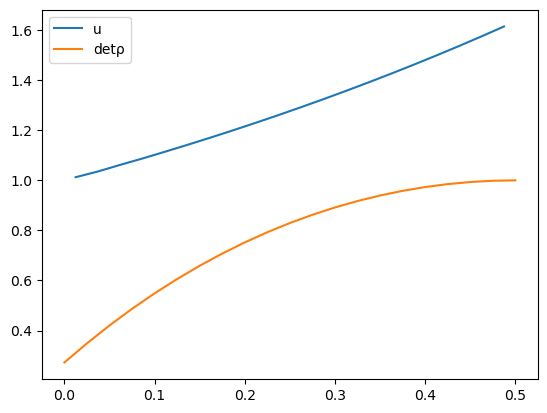

In [318]:
m,ρ,u = obj_np(ϕ,ret_mρu=True)
Tp = T[:-1]+dt/2
plt.plot(Tp,u[0],label='u')
plt.plot(T,lp.det(ρ),label='detρ')
plt.legend();

Newton solved works incredibly great in comparison. However, it does not scale to large instances.

In [319]:
%%time
ϕ = ad.Optimization.newton_minimize(lambda ϕ:obj_np(reshape_append0(ϕ,2)),ϕ0[:-1].reshape(-1))
m,ρ,u = obj_np(reshape_append0(ϕ,2),ret_mρu=True)

Initialization, objective 0.0
Iteration 1, Newton step 1.0, objective -0.5944272043597915.
Iteration 2, Newton step 1.0, objective -0.6773843469308294.
Iteration 3, Newton step 1.0, objective -0.6791932470719578.
Iteration 4, Newton step 1.0, objective -0.6791942561813157.
Iteration 5, Newton step 1.0, objective -0.6791942561853584.
Iteration 6, Newton step 1.0, objective -0.6791942561853586.
Convergence criterion satisfied, terminating.
Iteration 7, Newton step 0.5, objective -0.6791942561853584.
CPU times: user 184 ms, sys: 21.4 ms, total: 205 ms
Wall time: 191 ms


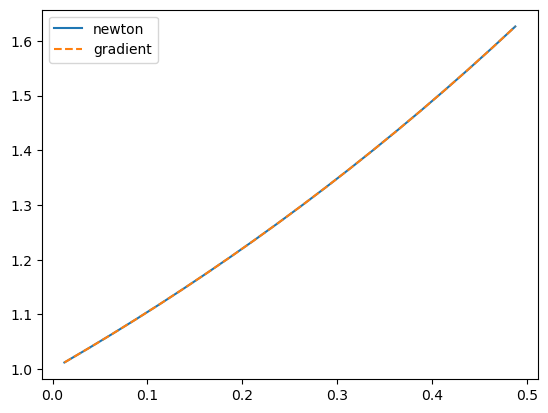

In [320]:
plt.plot(Tp,u_newton[0],label='newton')
plt.plot(Tp,u[0],label='gradient',linestyle='--')
plt.legend();

In [321]:
# Old implem
#%%time
#_,_,ρ_newton,u_newton = BB_newton(T,L,v0,ϵ)

Trying L-BFGS-B, which *should* scale reasonnably well, and give performance not too far from Newton.
In addition, there is a GPU-compatible implementation of LBFGS in pytorch.

In [322]:
%%time
Dobj_scipy = Df_flattened(Dobj_ti,ϕ0.shape)
res = minimize(Dobj_scipy,ϕ0.reshape(-1),jac=True,method='L-BFGS-B')
#Dobj_scipy(ϕ0.reshape(-1))

CPU times: user 464 ms, sys: 181 ms, total: 645 ms
Wall time: 580 ms


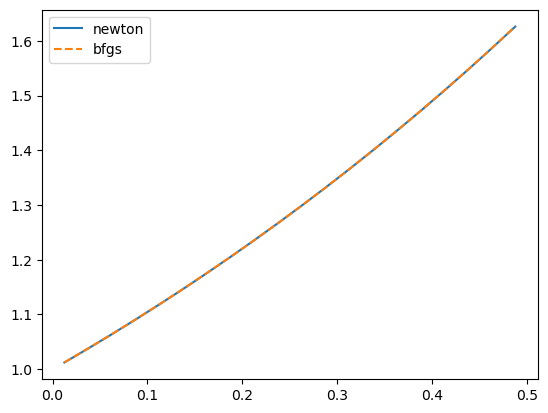

In [323]:
m_bfgs,ρ_bfgs,u_bfgs = obj_np(res['x'].reshape(ϕ0.shape),ret_mρu=True)
plt.plot(Tp,u_newton[0],label='newton')
plt.plot(Tp,u_bfgs[0],label='bfgs',linestyle='--')
plt.legend();

### 1.2 Exponential, playing with the weights

An issue with the original BBB formulation is that in only works on a limited time interval, in such way that the invertibility constraint $\det(\rho)>0$ is satisfied.
For the exponential, this happens if $\alpha<0$ at 
$$
    T = -\ln 3/\alpha \approx -0.549/\alpha.
$$

By introducing a weights function, we can extend the working interval.


In [333]:
T,dt = np.linspace(0,1,41,retstep=True)
Tp = T[:-1]+dt/2
L = L_Euler(-1)
v0 = np.array([1,1.])
γ = 2
ε = 1e-4

obj_ti,obj_np = mk_BBB_EDO(L,v0,dt,γ,ε)
Dobj_ti,Dobj_np = mk_DF_ti(obj_ti,True,True), mk_DF_np(obj_np)
ϕ0 = np.zeros((T.size,v0.size))
Dobj_scipy = Df_flattened(Dobj_ti,ϕ0.shape)

In [334]:
%%time
res = minimize(Dobj_scipy,ϕ0.reshape(-1),jac=True,method='L-BFGS-B')

[W 05/23/25 12:38:12.175 10555200] TaichiWarning
While compiling `obj_1_c361_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                                      ^^^^^^^^^^^^^^^^^^^^^^
Loading variable 205 before anything is stored to it.
[W 05/23/25 12:38:12.175 10555200] TaichiWarning
While compiling `obj_1_c361_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Loading variable 215 before anything is stored to it.
[W 05/23/25 12:38:12.175 10555200] TaichiWarning
While compiling `obj_1_c361_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hf

CPU times: user 4.1 s, sys: 1.21 s, total: 5.31 s
Wall time: 5.01 s


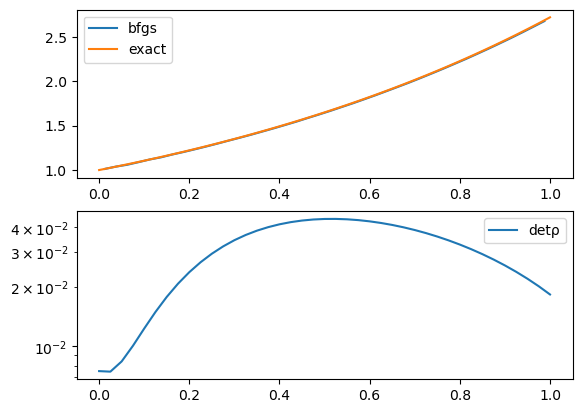

In [335]:
m_bfgs,ρ_bfgs,u_bfgs = obj_np(res['x'].reshape(ϕ0.shape),ret_mρu=True)
plt.subplot(211)
plt.plot(Tp,u_bfgs[0],label='bfgs')
plt.plot(T,np.exp(T),label='exact')
plt.legend();
plt.subplot(212)
plt.semilogy(T,lp.det(ρ_bfgs),label='detρ')
plt.legend();

In [327]:
T,dt = np.linspace(0,1.5,41,retstep=True)
Tp = T[:-1]+dt/2
L = L_Euler(-1)
v0 = np.array([1,1.])
γ = 4
ε = 0 #1e-5

obj_ti,obj_np = mk_BBB_EDO(L,v0,dt,γ,ε)
Dobj_ti,Dobj_np = mk_DF_ti(obj_ti,True,True), mk_DF_np(obj_np)
ϕ0 = np.zeros((T.size,v0.size))
Dobj_scipy = Df_flattened(Dobj_ti,ϕ0.shape)

In [328]:
%%time
res = minimize(Dobj_scipy,ϕ0.reshape(-1),jac=True,method='L-BFGS-B')

[W 05/23/25 12:37:21.023 10555199] TaichiWarning
While compiling `obj_1_c357_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                                      ^^^^^^^^^^^^^^^^^^^^^^
Loading variable 200 before anything is stored to it.
[W 05/23/25 12:37:21.023 10555199] TaichiWarning
While compiling `obj_1_c357_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Loading variable 210 before anything is stored to it.
[W 05/23/25 12:37:21.023 10555199] TaichiWarning
While compiling `obj_1_c357_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hf

CPU times: user 3.76 s, sys: 1.11 s, total: 4.87 s
Wall time: 4.6 s


One significant issue is that the decay rate $\gamma$ must be chosen large enough. 
If $\gamma$ is too small, then a maximum time $T_{\max}$ remains. If chosen evolution time $T>T_{\max}$ then the optimization crashes, or yields rubbish if the tolerance $\ve>0$ is too large.


Maybe we could turn this issue into an advantage: choose $\gamma$ in such way that it is only relevant to solve e.g. a dozen timesteps, and then use a moving window for the optimization.

<!---
When the decay $\gamma$ is large, the weight on the end of the interval becomes small.
As a result, the L-BFGS solver may not resolve well the last part of the EDO.

This is maybe not such bad news, and it suggests that a progressive strategy might work, where the computations are concentrated on some time sub-interval. However, it needs to be put in place correctly and carefully. 
--->

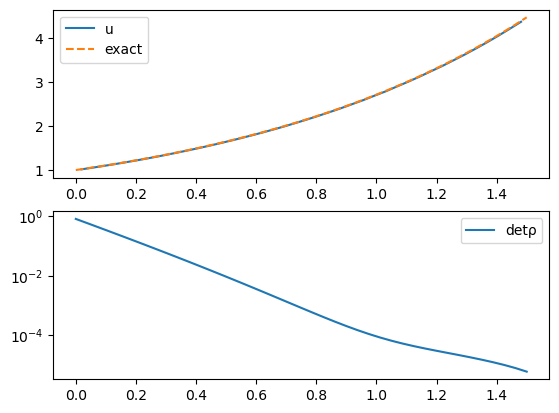

In [329]:
ϕ_bfgs = res['x'].reshape(ϕ0.shape)
m_bfgs,ρ_bfgs,u_bfgs = obj_np(ϕ_bfgs,ret_mρu=True)
plt.subplot(211)
plt.plot(Tp,u_bfgs[0],label='u')
plt.plot(T,np.exp(T),label='exact',linestyle='--')
plt.legend();
plt.subplot(212)
plt.semilogy(T,lp.det(ρ_bfgs),label='detρ')
plt.legend();

On this example, the unknown $\phi$ decays more or less like $\exp(-\gamma t)$ (until it approaches the terminal boundary condition $\phi(T)=0$). This is more or less expected. 
We could progressively freeze/unfreeze the $\phi$ unknowns, working on a time window $[T,T+T_w]$ such that $\exp(-\gamma T_w)$ is of the order of the desired solution precision. Maybe $\approx 20$ timesteps could be enough to get some of the advantages of the method without excessive numerical cost ?

Of course, this is not too far from the spirit of the similar moving window in Acharya et al.

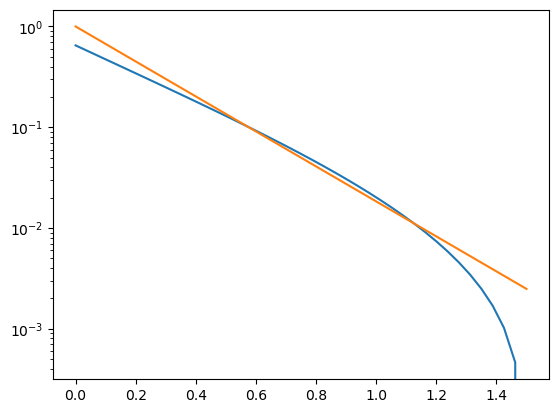

In [330]:
plt.semilogy(T,np.linalg.norm(ϕ_bfgs,axis=1))
plt.semilogy(T,np.exp(-γ*T))

In [331]:
%%time
ϕ = ad.Optimization.newton_minimize(lambda ϕ:obj_np(reshape_append0(ϕ,2)),ϕ0[:-1].reshape(-1))
m_newt,ρ_newt,u_newt = obj_np(reshape_append0(ϕ,2),ret_mρu=True)

Initialization, objective 0.0
Iteration 1, Newton step 1.0, objective -0.2973690137773514.
Iteration 2, Newton step 1.0, objective -0.3485144213020389.
Iteration 3, Newton step 1.0, objective -0.35692655165322373.
Iteration 4, Newton step 0.125, objective -0.3587321918726595.
Iteration 5, Newton step 0.125, objective -0.3591287929497512.
Iteration 6, Newton step 0.125, objective -0.35919251538858654.
Iteration 8, Newton step 0.5, objective -0.35943474742844683.
Iteration 10, Newton step 1.0, objective -0.359979276135555.
Iteration 12, Newton step 1.0, objective -0.36034934671811203.
Iteration 14, Newton step 1.0, objective -0.3603503483462187.
Convergence criterion satisfied, terminating.
Iteration 16, Newton step 0.5, objective -0.3603503483462187.
CPU times: user 102 ms, sys: 90.1 ms, total: 192 ms
Wall time: 137 ms


/Users/jean-mariemirebeau/Dropbox/Programmes/GithubM1/AdaptiveGridDiscretizations/agd/AutomaticDifferentiation/Base.py:46: RuntimeWarning: invalid value encountered in log
  def log(x):	y=1./x; return (np.log(x),y,-y**2)
/var/folders/pr/ywmc0vdj1_q45y494__w0nsr0000gn/T/ipykernel_1020/2784685254.py:39: RuntimeWarning: invalid value encountered in log
  - ε*τ*np.sum(Γ*np.log(lp.det(Lϕ))) ) # Positive definiteness enforcing penalty


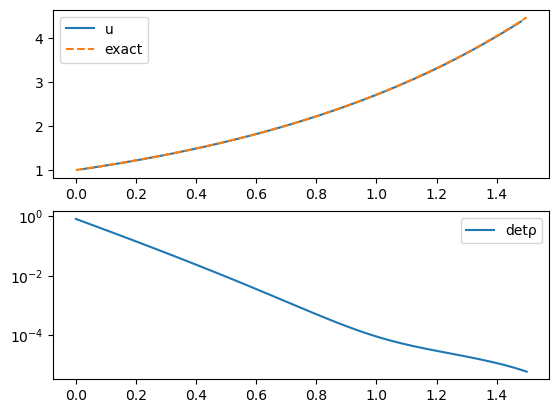

In [332]:
plt.subplot(211)
plt.plot(Tp,u_newt[0],label='u')
plt.plot(T,np.exp(T),label='exact',linestyle='--')
plt.legend();
plt.subplot(212)
plt.semilogy(T,lp.det(ρ_newt),label='detρ')
plt.legend();

### 1.3 Lotka-Volterra

In [641]:
T,dt = np.linspace(0,8,61,retstep=True)
Tp = T[:-1]+dt/2
v0 = np.array([1.5,1.3,1])
params = (1,1,1,1.)
L = L_LotkaVolterra(*params)

γ = 4
ε = 0 #1e-5

obj_ti,obj_np = mk_BBB_EDO(L,v0,dt,γ,ε)
Dobj_ti,Dobj_np = mk_DF_ti(obj_ti,True,True), mk_DF_np(obj_np)
ϕ0 = np.zeros((T.size,v0.size))
Dobj_scipy = Df_flattened(Dobj_ti,ϕ0.shape)

The Newton method works, but the difference in magnitude between the beginning and the end of the interval exceeds machine precision. Thus the stopping criterion fails, and an early abort is called.

In [642]:
%%time
ϕ = ad.Optimization.newton_minimize(lambda ϕ:obj_np(reshape_append0(ϕ,v0.size)),ϕ0[:-1].reshape(-1),
                                   δ_atol=0,δ_rtol=0,maxiter=30,step_min=1e-5)
ϕ = reshape_append0(ϕ,v0.size)
m_newt,ρ_newt,u_newt = obj_np(ϕ,ret_mρu=True)

Initialization, objective 0.0
Iteration 1, Newton step 1.0, objective -0.571284284231755.
Iteration 2, Newton step 1.0, objective -0.5864756126064589.
Iteration 3, Newton step 1.0, objective -0.586674606969469.
Iteration 4, Newton step 1.0, objective -0.5866747658516059.
Iteration 5, Newton step 1.0, objective -0.5866747659362923.
Iteration 6, Newton step 1.0, objective -0.5866747659364366.
Iteration 8, Newton step 0.125, objective -0.5866747659364371.
Warning minimal step size 1.52587890625e-05 deteriorates objective
Iteration 10, Newton step 3.0517578125e-05, objective -0.586674765936437.
Warning minimal step size 1.52587890625e-05 deteriorates objective
Stalling, aborting
Iteration 11, Newton step 1.52587890625e-05, objective -0.586674765936437.
CPU times: user 669 ms, sys: 401 ms, total: 1.07 s
Wall time: 1.02 s


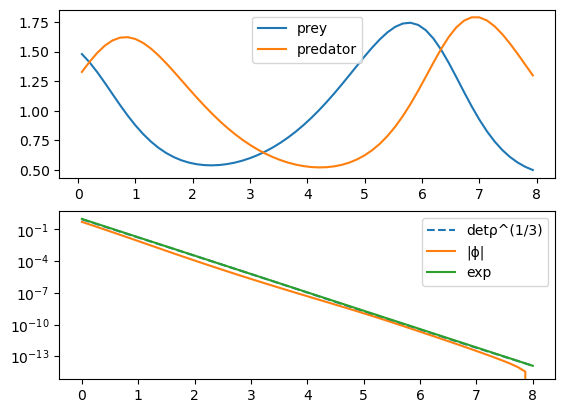

In [643]:
plt.subplot(211)
plt.plot(Tp,u_newt[0],label='prey')
plt.plot(Tp,u_newt[1],label='predator')
plt.legend()
plt.subplot(212)
plt.semilogy(T,lp.det(ρ_newt)**(1/3),linestyle='--',label='detρ^(1/3)')
plt.semilogy(T,np.linalg.norm(ϕ,axis=1),label='|ϕ|')
plt.semilogy(T,np.exp(-γ*T),label='exp')
plt.legend();

In [646]:
T,dt = np.linspace(0,2,15,retstep=True)
Tp = T[:-1]+dt/2
v0 = np.array([1.5,1.3,1])
params = (1,1,1,1.)
L = L_LotkaVolterra(*params)

γ = 4
ε = 0 #1e-5

obj_ti,obj_np = mk_BBB_EDO(L,v0,dt,γ,ε)
Dobj_ti,Dobj_np = mk_DF_ti(obj_ti,True,True), mk_DF_np(obj_np)
ϕ0 = np.zeros((T.size,v0.size))
Dobj_scipy = Df_flattened(Dobj_ti,ϕ0.shape)

res = minimize(Dobj_scipy,ϕ0.reshape(-1),jac=True,method='L-BFGS-B')

[W 05/23/25 18:28:16.481 10555202] TaichiWarning
While compiling `obj_1_c557_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                                      ^^^^^^^^^^^^^^^^^^^^^^
Loading variable 454 before anything is stored to it.
[W 05/23/25 18:28:16.481 10555202] TaichiWarning
While compiling `obj_1_c557_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                                      ^^^^^^^^^^^^^^^^^^^^^^
Loading variable 456 before anything is stored to it.
[W 05/23/25 18:28:16.481 10555202] TaichiWarning
While compiling `obj_1_c557_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hf

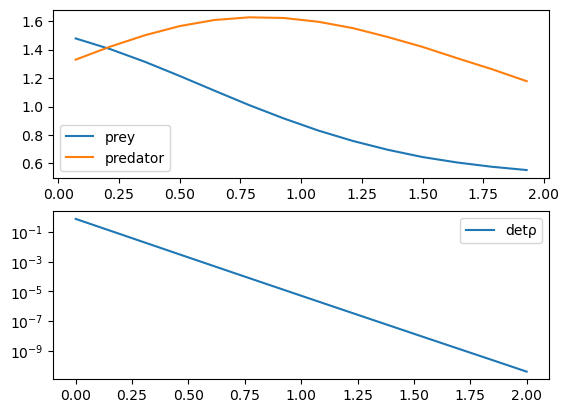

In [648]:
ϕ_bfgs = res['x'].reshape(ϕ0.shape)
m_bfgs,ρ_bfgs,u_bfgs = obj_np(ϕ_bfgs,ret_mρu=True)
plt.subplot(211)
plt.plot(Tp,u_bfgs[0],label='prey')
plt.plot(Tp,u_bfgs[1],label='predator')
plt.legend();
plt.subplot(212)
plt.semilogy(T,lp.det(ρ_bfgs),label='detρ')
plt.legend();

## 2. Progressive solution

We investigate the numerical solution of the BBB formulation of EDOs using a progressive time window.

### 2.1 Newton method

In [558]:
def obj(ϕ,L,γ,dt,v0,ϵ,ret_mρu=False):
    ϕ = ϕ.copy(); 
    ϕ[-1]=0
    Lϕ = sum(ϕ[None,None,:,i]*L[i,:,:,None] for i in range(d))
    Γ = np.exp(-γ*dt*(np.arange(len(ϕ))-1)) 
    for i in range(len(L)): Lϕ[i,i] += Γ
    iLϕ = lp.inverse(Lϕ)
    Dtϕ = (ϕ[1:]-ϕ[:-1]).T/dt
    iLϕ = 0.5*(iLϕ[:,:,1:]+iLϕ[:,:,:-1]) # Harmonic mean
    if ret_mρu: return Dtϕ,Lϕ,lp.dot_AV(iLϕ,Dtϕ)
    return ( 0.5*dt*np.sum(lp.dot_VAV(Dtϕ,iLϕ,Dtϕ) )  # Perspective function
        + lp.dot_VV(ϕ[1],v0) # 'Initial' condition at time 1 !!
        - ε*dt*np.sum(Γ*np.log(lp.det(Lϕ))) ) # Positive definiteness enforcing penalty

def obj_bd(ϕ,ϕi=None): 
    """Prepends an initial condition ϕi, and appends a terminal condition ϕf, before calling obj"""
    shape = ϕi if isinstance(ϕi,tuple) else ϕi.shape
    ϕ = ϕ.reshape((-1,*shape))
    if isinstance(ϕi,tuple): ϕi = ad.remove_ad(ϕ[0]) # Neutralize initial boundary condition
    ϕf = np.zeros_like(ϕi)
    return np.concatenate((ϕi[None],ϕ,ϕf[None]),axis=0)

def progressive_solve(single_solve,stepcount,stepsize,window,
                      L,γ,dt,v0,*args,**kwargs):
    ϕtot = []
    ϕi = (len(L),)
    Γ = np.exp(-γ*dt*stepsize)
    for i in range(stepcount):
        if i==0: ϕ = np.zeros((window,len(L)))
        else: 
            ϕ /= Γ # Rescale, for better behavior of solvers, since ϕ(t) = O( exp(-γ t) )
            ϕi = ϕ[stepsize-1].copy() # Initial condition comes from the last entry
            ϕ[:-stepsize] = ϕ[stepsize:] # Shift entries
            ϕ[-stepsize:]=0 # Append trailing zeros
            v0=np.zeros_like(v0) # Initial condition only for the first round
        ϕ = single_solve(ϕ,ϕi,L,γ,dt,v0,*args,**kwargs)
        ϕtot.append(ϕ*Γ**i)
    ϕcat = [ϕ[:stepsize] for ϕ in ϕtot[:-1]]+[ϕtot[-1],np.zeros_like(ϕ[:1])]
    return np.concatenate(ϕcat,axis=0),ϕtot

def newton_solve_BBB_EDO(ϕ0,ϕi,*args,verbosity=0,maxiter=100,**kwargs):
    """Solve the BBB formulation of an EDO, on a sufficiently small time interval."""
    return ad.Optimization.newton_minimize(lambda ϕ:obj(obj_bd(ϕ,ϕi),*args,**kwargs),
                ϕ0.reshape(-1),verbosity=verbosity,maxiter=maxiter).reshape(ϕ0.shape)        

In [559]:
dt = 0.05
v0 = np.array([1.5,1.3,1])
params = (1,1,1,1.)
L = L_LotkaVolterra(*params)
γ = 4
ε = 0 #1e-5

args = L,γ,dt,v0,ϵ
step = (newton_solve_BBB_EDO,2,20,60)
print(f"Big enough : {np.exp(-γ*step[1]*dt)}, Small enough : {np.exp(-γ*step[2]*dt)}")
ϕ,_ = progressive_solve(*step,*args)
m,ρ,u = obj(ϕ,*args,ret_mρu=True)

Big enough : 0.6703200460356393, Small enough : 0.01831563888873418
Initialization, objective 0.0
Convergence criterion satisfied, terminating.
Iteration 59, Newton step 1.0, objective -0.6094946438613122.
Initialization, objective 0.548077371073623
Convergence criterion satisfied, terminating.
Iteration 6, Newton step 1.0, objective 0.5479983043255373.


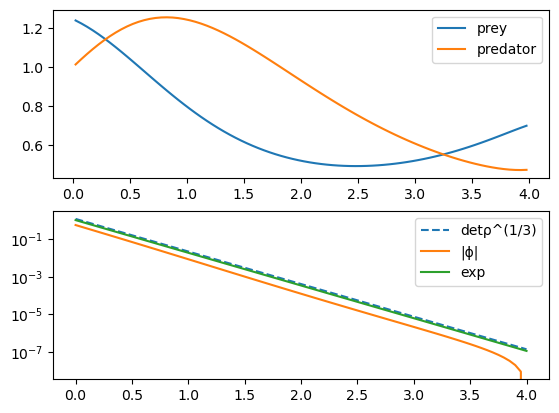

In [560]:
T = np.arange(len(ϕ))*dt
Tp = T[:-1]+dt/2
plt.subplot(211)
plt.plot(Tp,u[0],label='prey')
plt.plot(Tp,u[1],label='predator')
plt.legend()
plt.subplot(212)
plt.semilogy(T,lp.det(ρ)**(1/3),linestyle='--',label='detρ^(1/3)')
plt.semilogy(T,np.linalg.norm(ϕ,axis=1),label='|ϕ|')
plt.semilogy(T,np.exp(-γ*T),label='exp')
plt.legend();

In [553]:
step = (20,20,60)
ϕ,ϕtot = progressive_solve(*step,*args)
print(f"Big enough : {np.exp(-γ*step[1]*dt)}, Small enough : {np.exp(-γ*step[2]*dt)}")
m,ρ,u = obj(ϕ,*args,ret_mρu=True)

Initialization, objective 0.0
Convergence criterion satisfied, terminating.
Iteration 59, Newton step 1.0, objective -0.6094946438613122.
Initialization, objective 0.548077371073623
Convergence criterion satisfied, terminating.
Iteration 6, Newton step 1.0, objective 0.5479983043255373.
Initialization, objective 0.35273570852810954
Convergence criterion satisfied, terminating.
Iteration 6, Newton step 1.0, objective 0.35264412124759736.
Initialization, objective 0.2967769441050547
Convergence criterion satisfied, terminating.
Iteration 6, Newton step 0.5, objective 0.2966345589788465.
Initialization, objective 0.3715024765275515
Convergence criterion satisfied, terminating.
Iteration 6, Newton step 1.0, objective 0.37130466818299496.
Initialization, objective 0.5733378013672875
Convergence criterion satisfied, terminating.
Iteration 7, Newton step 1.0, objective 0.5731529273338608.
Initialization, objective 0.732559987336972
Convergence criterion satisfied, terminating.
Iteration 7, Ne

Note that it would be resolutely impossible to solve this pb without time windowing and rescaling, given that $\det(\rho)$ is much below machin precision at the end.

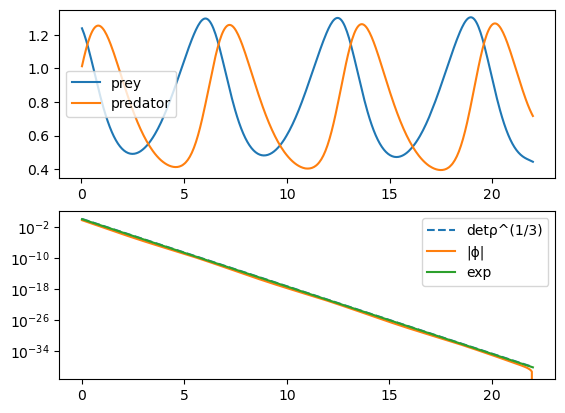

In [554]:
T = np.arange(len(ϕ))*dt
Tp = T[:-1]+dt/2
plt.subplot(211)
plt.plot(Tp,u[0],label='prey')
plt.plot(Tp,u[1],label='predator')
plt.legend()
plt.subplot(212)
plt.semilogy(T,lp.det(ρ)**(1/3),linestyle='--',label='detρ^(1/3)')
plt.semilogy(T,np.linalg.norm(ϕ,axis=1),label='|ϕ|')
plt.semilogy(T,np.exp(-γ*T),label='exp')
plt.legend();

### 2.1 L-BFGS solver with Taichi autodiff

On these examples, this approach is not so convincing : 
- the LBFGS solver needs many iterations, leading to slow runtimes.
- the LBFGS solver is much less accurate than Newton. The stopping criterion seems to accept relative errors of the order of 10^-5. When this is combined with the exponentially decaying weight, and the finite differences, we get a rather inaccurate solution.
- (Taichi autodiff seems to have a problem with matmul, and yells insults without reason.)

In [636]:
@ti.data_oriented
class lbfgs_solve_BBB_EDO:
    def __init__(self,window,d):
        self.window = window;  self.d = d
        self.L = ti.Matrix.field(d,d,float_t,shape=d) 
        self.v0 = ti.Vector.field(d,float_t,shape=())
        self.ϕ_ad = ti.Vector.field(d,float_t,window+2,needs_grad=True); self.ϕ_ad.fill(0)
        self.res_ad = ti.field(float,shape=(),needs_grad=True)

    @ti.kernel
    def obj_1(self,ϕ:ti.template(),res:ti.template()):
        N,ε4τ2,L,γ,dt,v0,d = ti.static(ϕ.shape[0],self.ε*4*self.dt**2,self.L,self.γ,self.dt,self.v0,self.d)
        for n in ϕ:
            Γ = ti.math.exp(-γ*(n-1)*dt)
            Lϕ = Γ * ti.math.eye(d)
            for i in ti.static(range(d)): Lϕ += ϕ[n][i]*L[i]
            iLϕ = ti.math.inverse(Lϕ)
            if n<N-1: Dtϕ = ϕ[n+1]-ϕ[n]; res[None] += Dtϕ @ iLϕ @ Dtϕ 
            if n>0:   Dtϕ = ϕ[n]-ϕ[n-1]; res[None] += Dtϕ @ iLϕ @ Dtϕ 
            res[None] -= ε4τ2*Γ*ti.log(ti.math.determinant(Lϕ))
    @ti.kernel # Autodiff requires splitting the kernels (for vs non-for operations)
    def obj_2(self,ϕ:ti.template(),res:ti.template()):
        dt,v0 = ti.static(self.dt,self.v0)
        res[None] = res[None]/(4*dt) + ϕ[1] @ v0[None]         
    def obj_(self,ϕ,res): res[None]=0; self.obj_1(ϕ,res); self.obj_2(ϕ,res) # Assumes ϕ[-1]=0

    @ti.kernel
    def copy_ϕ(self,ϕ:ti.types.ndarray(float_t,ndim=2)):
        ϕ_ad = ti.static(self.ϕ_ad)
        for t,x in ϕ : ϕ_ad[t+1][x] = ϕ[t,x]
    @ti.kernel
    def copy_ϕ_init(self,ϕ:ti.types.ndarray(float_t,ndim=2)):
        ϕ_ad = ti.static(self.ϕ_ad)
        for x in ti.ndrange(ϕ.shape[1]): ϕ_ad[0][x] = ϕ[0,x]
            
    @ti.kernel
    def copy_ϕi(self,ϕi:ti.types.ndarray(float_t,ndim=1)):
        ϕ_ad = ti.static(self.ϕ_ad)
        for   x in ϕi: ϕ_ad[0][x] = ϕi[x]

    def Dobj(self,ϕ):
        ϕ = ϕ.reshape(self.window,self.d)
        self.copy_ϕ(ϕ)
        if not self.has_ϕi: self.copy_ϕ_init(ϕ)
        with ti.ad.Tape(loss=self.res_ad): self.obj_(self.ϕ_ad,self.res_ad)
        return self.res_ad[None], self.ϕ_ad.grad.to_numpy()[1:-1].reshape(-1)

    def __call__(self,ϕ0,ϕi,L,γ,dt,v0,ϵ):
        """Minimize the objective using L-BFGS"""
        self.has_ϕi = not isinstance(ϕi,tuple)
        if self.has_ϕi: self.copy_ϕi(ϕi)
        self.L.from_numpy(L)
        self.v0.from_numpy(v0)
        self.γ,self.dt,self.ϵ = float(γ),float(dt),float(ϵ) # Unsure if this is taken into account.
        res = minimize(self.Dobj,ϕ0.reshape(-1),jac=True,method='L-BFGS-B')
        print(res)
        return res['x'].reshape(ϕ0.shape)

In [639]:
dt = 0.05
v0 = np.array([1.5,1.3,1])
params = (1,1,1,1.)
L = L_LotkaVolterra(*params)
γ = 4
ε = 0 #1e-5

args = L,γ,dt,v0,ϵ
window=40
lbfgs = lbfgs_solve_BBB_EDO(window,len(v0))
newton = newton_solve_BBB_EDO

#step = (lbfgs_solve_BBB_EDO(window,len(v0)),1,20,window)

d=len(v0)
ϕ = np.zeros((window,d))
ϕi = np.array([-0.2,-0.2,-0.2])
ϕ_newton = newton(ϕ,ϕi,L,γ,dt,v0,ϵ)
ϕ_lbfgs = lbfgs(ϕ,ϕi,L,γ,dt,v0,ϵ)
ϕ_newton,ϕ_lbfgs

Initialization, objective 1.1005170060972802
Convergence criterion satisfied, terminating.
Iteration 7, Newton step 1.0, objective -0.5301859334780966.


[W 05/23/25 18:22:42.976 10555199] TaichiWarning
While compiling `obj_1_c539_1_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                                      ^^^^^^^^^^^^^^^^^^^^^^
Loading variable 452 before anything is stored to it.
[W 05/23/25 18:22:42.976 10555199] TaichiWarning
While compiling `obj_1_c539_1_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                                      ^^^^^^^^^^^^^^^^^^^^^^
Loading variable 454 before anything is stored to it.
[W 05/23/25 18:22:42.976 10555199] TaichiWarning
While compiling `obj_1_c539_1_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hf

      fun: -0.5301856438781521
 hess_inv: <120x120 LbfgsInvHessProduct with dtype=float64>
      jac: array([ 1.90027034e-04,  9.48275912e-05,  2.94812705e-04,  5.07635578e-04,
       -3.11174980e-04, -7.59838557e-06,  2.06979817e-04, -9.14880862e-04,
        7.10572089e-04,  3.19787354e-04, -1.03985333e-04, -5.84691666e-04,
       -6.19513785e-04,  7.21792442e-04,  8.47970433e-05,  4.25237227e-04,
       -5.29418528e-04, -1.37321812e-04, -1.69648708e-04, -4.21485933e-04,
       -7.39424824e-04,  7.02894744e-04, -2.66267237e-04,  4.27658363e-04,
        6.99188898e-04, -4.71255689e-04,  5.22595071e-04, -1.35747023e-04,
        6.05908141e-04,  1.65732178e-04, -3.38192792e-04, -7.95966901e-04,
        3.76768316e-04,  1.06119771e-03, -3.73258133e-04, -6.45698838e-04,
       -2.39544118e-04,  2.25006884e-05, -1.15151848e-04,  7.09094177e-04,
       -4.52701503e-04, -6.02757194e-04,  2.89068495e-04,  6.36175332e-04,
        2.94507815e-04, -5.55943220e-04, -1.45078606e-03, -1.07545554e-04

(array([[-2.38499354e-01, -2.10773938e-01, -2.11541116e-01],
        [-1.93752858e-01, -1.71762713e-01, -1.73123062e-01],
        [-1.57423245e-01, -1.39911436e-01, -1.41717160e-01],
        [-1.27924792e-01, -1.13919439e-01, -1.16035021e-01],
        [-1.03970539e-01, -9.27194437e-02, -9.50267489e-02],
        [-8.45160868e-02, -7.54362867e-02, -7.78364564e-02],
        [-6.87139316e-02, -6.13528152e-02, -6.37661316e-02],
        [-5.58763727e-02, -4.98817440e-02, -5.22462890e-02],
        [-4.54453934e-02, -4.05424435e-02, -4.28121170e-02],
        [-3.69682072e-02, -3.29418140e-02, -3.50840879e-02],
        [-3.00774072e-02, -2.67585381e-02, -2.87521888e-02],
        [-2.44748558e-02, -2.17301259e-02, -2.35630916e-02],
        [-1.99186110e-02, -1.76422653e-02, -1.93097116e-02],
        [-1.62123202e-02, -1.43200752e-02, -1.58227039e-02],
        [-1.31966139e-02, -1.16209253e-02, -1.29635375e-02],
        [-1.07421259e-02, -9.42854760e-03, -1.06188499e-02],
        [-8.74383034e-03

In [640]:
ϕ_newton-ϕ_lbfgs

array([[-4.12288315e-05,  5.33509877e-05, -5.57267520e-05],
       [-6.98248552e-05,  9.49501139e-05, -8.07411184e-05],
       [-7.85658360e-05,  1.16582444e-04, -9.16632730e-05],
       [-7.54036441e-05,  1.02092784e-04, -7.05360964e-05],
       [-6.83204072e-05,  9.07023026e-05, -6.47052518e-05],
       [-7.61275296e-05,  9.60995769e-05, -6.29135622e-05],
       [-7.70678108e-05,  9.18763655e-05, -5.89413196e-05],
       [-8.31834615e-05,  8.49096224e-05, -6.40358500e-05],
       [-7.98951381e-05,  7.54564605e-05, -6.03981279e-05],
       [-6.98057886e-05,  6.29252617e-05, -5.01614184e-05],
       [-6.24692351e-05,  5.74678843e-05, -4.14363772e-05],
       [-5.79216280e-05,  4.79564227e-05, -3.12062677e-05],
       [-4.93764865e-05,  3.91035624e-05, -2.44453520e-05],
       [-4.33609818e-05,  3.25287679e-05, -1.96315288e-05],
       [-3.64120179e-05,  2.64381411e-05, -1.69577227e-05],
       [-2.98451333e-05,  2.35505295e-05, -1.41910977e-05],
       [-2.56774785e-05,  1.84099683e-05

In [652]:
T,dt = np.linspace(0,2,15,retstep=True)
dt

0.14285714285714285

In [667]:
%%time
dt = 0.05
v0 = np.array([1.5,1.3,1])
params = (1,1,1,1.)
L = L_LotkaVolterra(*params)
γ = 4
ε = 0 #1e-5

args = L,γ,dt,v0,ϵ
window=60
step = (lbfgs_solve_BBB_EDO(window,len(v0)),1,5,window)
print(f"Big enough : {np.exp(-γ*step[1]*dt)}, Small enough : {np.exp(-γ*step[2]*dt)}")
ϕ,_ = progressive_solve(*step,*args)
m,ρ,u = obj(ϕ,*args,ret_mρu=True)

Big enough : 0.8187307530779818, Small enough : 0.36787944117144233


[W 05/23/25 18:42:01.958 10555200] TaichiWarning
While compiling `obj_1_c539_5_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                                      ^^^^^^^^^^^^^^^^^^^^^^
Loading variable 452 before anything is stored to it.
[W 05/23/25 18:42:01.958 10555200] TaichiWarning
While compiling `obj_1_c539_5_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                                      ^^^^^^^^^^^^^^^^^^^^^^
Loading variable 454 before anything is stored to it.
[W 05/23/25 18:42:01.958 10555200] TaichiWarning
While compiling `obj_1_c539_5_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hf

      fun: -0.6094826586687568
 hess_inv: <180x180 LbfgsInvHessProduct with dtype=float64>
      jac: array([ 1.43503981e-03, -1.49296072e-03,  6.87168928e-04, -1.80447345e-03,
       -2.46004443e-03,  1.52283341e-03,  6.26589892e-04, -8.44590464e-04,
        3.79779925e-04, -1.80019063e-04, -1.12545398e-03, -2.15520091e-04,
        2.15290632e-03, -1.50251063e-03,  6.75484716e-04, -1.12085801e-03,
       -2.33918853e-03, -1.69644450e-03, -1.77647470e-03, -2.37306225e-03,
        1.28656142e-03, -1.77874634e-03,  2.03889297e-03, -3.55979176e-03,
        2.83135846e-03,  1.93103851e-04,  3.28168905e-03,  2.77960401e-04,
       -4.65475734e-04, -1.01346014e-03,  1.92931916e-03, -3.57538057e-03,
        3.23115788e-04,  2.51588396e-03,  2.21037050e-03, -4.58976818e-04,
       -1.07565895e-03,  2.19705218e-03, -4.65315966e-04,  2.90825942e-04,
        1.46597009e-03, -1.46041767e-03,  1.13822091e-03, -3.09490716e-04,
        2.97913264e-03,  2.03750530e-03, -6.41120922e-04, -3.96387111e-03

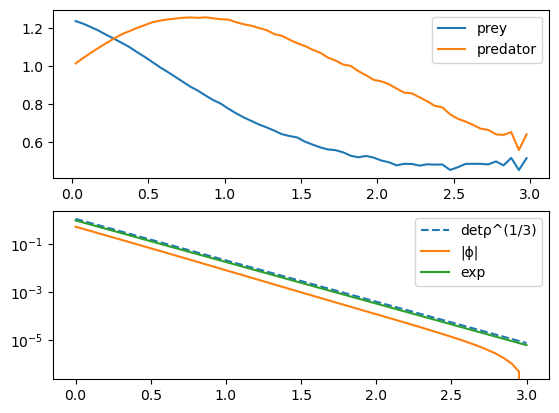

In [669]:
T = np.arange(len(ϕ))*dt
Tp = T[:-1]+dt/2
plt.subplot(211)
plt.plot(Tp,u[0],label='prey')
plt.plot(Tp,u[1],label='predator')
plt.legend()
plt.subplot(212)
plt.semilogy(T,lp.det(ρ)**(1/3),linestyle='--',label='detρ^(1/3)')
plt.semilogy(T,np.linalg.norm(ϕ,axis=1),label='|ϕ|')
plt.semilogy(T,np.exp(-γ*T),label='exp')
plt.legend();

In [665]:
%%time
#T,dt = np.linspace(0,2,15,retstep=True)
dt = 0.05
T = dt*np.arange(60)
Tp = T[:-1]+dt/2
v0 = np.array([1.5,1.3,1])
params = (1,1,1,1.)
L = L_LotkaVolterra(*params)

γ = 4
ε = 0 #1e-5

obj_ti,obj_np = mk_BBB_EDO(L,v0,dt,γ,ε)
Dobj_ti,Dobj_np = mk_DF_ti(obj_ti,True,True), mk_DF_np(obj_np)
ϕ0 = np.zeros((T.size,v0.size))
Dobj_scipy = Df_flattened(Dobj_ti,ϕ0.shape)

res = minimize(Dobj_scipy,ϕ0.reshape(-1),jac=True,method='L-BFGS-B')

[W 05/23/25 18:40:26.921 10555200] TaichiWarning
While compiling `obj_1_c585_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                                      ^^^^^^^^^^^^^^^^^^^^^^
Loading variable 454 before anything is stored to it.
[W 05/23/25 18:40:26.921 10555200] TaichiWarning
While compiling `obj_1_c585_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hfm_dev_311/lib/python3.11/site-packages/taichi/lang/matrix_ops.py", line 274, in _matmul_helper:
                vec_z[i] = vec_z[i] + mat_x[i, j] * mat_y[j]
                                      ^^^^^^^^^^^^^^^^^^^^^^
Loading variable 456 before anything is stored to it.
[W 05/23/25 18:40:26.921 10555200] TaichiWarning
While compiling `obj_1_c585_0_reverse_grad`, File "/Users/jean-mariemirebeau/opt/miniconda3/envs/agd-hf

CPU times: user 58 s, sys: 17 s, total: 1min 14s
Wall time: 1min 10s


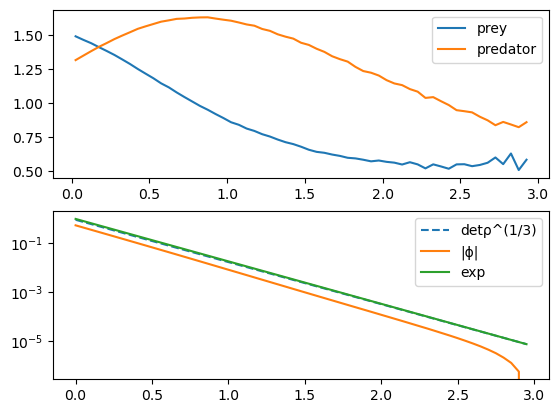

In [666]:
ϕ_bfgs = res['x'].reshape(ϕ0.shape)
m_bfgs,ρ_bfgs,u_bfgs = obj_np(ϕ_bfgs,ret_mρu=True)
plt.subplot(211)
plt.plot(Tp,u_bfgs[0],label='prey')
plt.plot(Tp,u_bfgs[1],label='predator')
plt.legend();
plt.subplot(212)
plt.semilogy(T,lp.det(ρ_bfgs)**(1/3),linestyle='--',label='detρ^(1/3)')
plt.semilogy(T,np.linalg.norm(ϕ_bfgs,axis=1),label='|ϕ|')
plt.semilogy(T,np.exp(-γ*T),label='exp')
plt.legend();